In [14]:
import pandas as pd

Let's grab our dataframe from our EDA script:

In [15]:
df_clash = pd.read_pickle("../data/clash_royale_to_model.pkl")
cards = pd.read_csv("../data/cards.csv")

We know beforehand that some cards are strong individually, and other cards require "partner" cards to perform well. As such, the connections between cards will be nonlinear. There is no set size group which we know is the best to analyze.

For these reasons, a Decision Tree classifier is a strong choice, as we are working with non-linearly separable data in a supervised learning problem. We will elect to go with XGBoost.

Let's drop the columns that might cause leakage. We don't want the model to memorize strong players, or players that play in strong clans, so we will drop those features irrelevant to our problem.

In [16]:
def make_long(df: pd.DataFrame) -> pd.DataFrame:
    # winners
    w = pd.DataFrame({
        "battleTime": df["battleTime"],
        "arena.id": df["arena.id"],
        "gameMode.id": df["gameMode.id"],
        "startingTrophies.p": df["winner.startingTrophies"],
        "startingTrophies.o": df["loser.startingTrophies"],
        "trophyChange.p": df["winner.trophyChange"],
        "trophyChange.o": df["loser.trophyChange"],
        "elixir.p": df["winner.elixir.average"],
        "elixir.o": df["loser.elixir.average"],
        "total_level.p": df["winner.totalcard.level"],
        "total_level.o": df["loser.totalcard.level"],
        "troop_count.p": df["winner.troop.count"],
        "troop_count.o": df["loser.troop.count"],
        "spell_count.p": df["winner.spell.count"],
        "spell_count.o": df["loser.spell.count"],
        "structure_count.p": df["winner.structure.count"],
        "structure_count.o": df["loser.structure.count"],
        "cards.p": df["winner.cards.list"], #cards for this player
        "cards.o": df["loser.cards.list"], #cards for the opponent
        "y": 1
    })

    # losers
    l = pd.DataFrame({
        "battleTime": df["battleTime"],
        "arena.id": df["arena.id"],
        "gameMode.id": df["gameMode.id"],
        "startingTrophies.p": df["loser.startingTrophies"],
        "startingTrophies.o": df["winner.startingTrophies"],
        "trophyChange.p": df["loser.trophyChange"],
        "trophyChange.o": df["winner.trophyChange"],
        "elixir.p": df["loser.elixir.average"],
        "elixir.o": df["winner.elixir.average"],
        "total_level.p": df["loser.totalcard.level"],
        "total_level.o": df["winner.totalcard.level"],
        "troop_count.p": df["loser.troop.count"],
        "troop_count.o": df["winner.troop.count"],
        "spell_count.p": df["loser.spell.count"],
        "spell_count.o": df["winner.spell.count"],
        "structure_count.p": df["loser.structure.count"],
        "structure_count.o": df["winner.structure.count"],
        "cards.p": df["loser.cards.list"], #cards for this player
        "cards.o": df["winner.cards.list"], #cards for the opponent
        "y": 0
    })

    out = pd.concat([w, l], ignore_index=True)
    return out

Now, we use multi-hot encoding to encode our decks. This is because we will have eight cards on each player's deck vector that are in their deck, so we cannot use one-hot encoding.

Below, we characterize a class DeckBinarizer that will allow us to multi-hot encode the player's decks (do relevant operations).

In [19]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer

id_to_name = dict(zip(cards["card_id"], cards["card_name"]))

class DeckBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, colname: str, prefix: str, id_to_name: dict = None):
        self.colname = colname
        self.prefix = prefix
        self.id_to_name = id_to_name
        self.mlb = MultiLabelBinarizer(sparse_output=True)

    def fit(self, X, y=None):
        self.mlb.fit(X[self.colname])
        return self

    def transform(self, X):
        M = self.mlb.transform(X[self.colname])
        return M

    def get_feature_names_out(self, input_features=None):
        feature_names = []
        for card_id in self.mlb.classes_:
            if self.id_to_name is not None:
                card_name = self.id_to_name.get(card_id, str(card_id))
            else:
                card_name = str(card_id)
            feature_names.append(f"{self.prefix}{card_name}")
        return np.array(feature_names, dtype=object)

Now, let's train the model!

In [20]:
import ast
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


#Sort by battle times to adjust for popular strategies changing:
#Although not applicable for our particular project, would be useful if there
#was more 
df_sorted = df_clash.sort_values("battleTime").reset_index(drop=True)
split_idx = int(0.8 * len(df_sorted))

train_battles = df_sorted.iloc[:split_idx]
test_battles  = df_sorted.iloc[split_idx:]

train_df = make_long(train_battles)
test_df  = make_long(test_battles)

def ensure_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []

train_df["cards.p"] = train_df["cards.p"].map(ensure_list)
train_df["cards.o"] = train_df["cards.o"].map(ensure_list)
test_df["cards.p"] = test_df["cards.p"].map(ensure_list)
test_df["cards.o"] = test_df["cards.o"].map(ensure_list)

y_train = train_df["y"].astype(int)
y_test  = test_df["y"].astype(int)

# Drop non-feature cols
X_train = train_df.drop(columns=["y", "battleTime", "battle_id"], errors="ignore")
X_test  = test_df.drop(columns=["y", "battleTime", "battle_id"], errors="ignore")

cat_cols = ["arena.id", "gameMode.id"]
num_cols = [
    "startingTrophies.p","startingTrophies.o",
    "elixir.p","elixir.o",
    "total_level.p","total_level.o",
    "spell_count.p","spell_count.o",
    "structure_count.p","structure_count.o",
]

preprocess = ColumnTransformer(
    transformers=[
        ("cats", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("nums", "passthrough", num_cols),
        ("deck_p", DeckBinarizer("cards.p", "", id_to_name), ["cards.p"]),
        ("deck_o", DeckBinarizer("cards.o", "", id_to_name), ["cards.o"]),
    ],
    remainder="drop",
)

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state = 1
)

pipe = Pipeline([
    ("prep", preprocess),
    ("xgb", model),
])

pipe.fit(X_train, y_train)


,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cats', ...), ('nums', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score

proba = pipe.predict_proba(X_test)[:, 1] #Extracts predicted win probabilities from model
pred = (proba >= 0.5).astype(int) #binarizes win = 1, loss = 0

print("Baseline win rate:", y_test.mean())
print("AUC:", roc_auc_score(y_test, proba)) #Here we measure the likelihood a winning deck was ranked above a losing deck
print("Acc:", accuracy_score(y_test, pred))

Baseline win rate: 0.5
AUC: 0.6439864720499012
Acc: 0.5995836771700672


As our Area Under the Curve (AUC) is 0.61 > 0.5, we have reason to believe that our model performs better than a random guess. It is important to note that although our AUC and Accuracy scores are not high, this is to be expected, because player skill plays a very large factor in game outcomes, although we don't have data on that.

Now we find feature importance.

In [23]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["xgb"].feature_importances_

fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

# Player and Opponent card-only importance
player_cards = fi[fi["feature"].astype(str).str.startswith("deck_p__")].copy()
opp_cards = fi[fi["feature"].astype(str).str.startswith("deck_o__")].copy()

print("\nTop 15 PLAYER deck card features:")
display(player_cards.head(15))

print("\nTop 15 OPPONENT deck card features:")
display(opp_cards.head(15))


Top 15 PLAYER deck card features:


,feature,importance
2,deck_p__Archers,0.028326
5,deck_p__Giant,0.023279
6,deck_p__Musketeer,0.021795
10,deck_p__Elixir Golem,0.010020
12,deck_p__Barbarian Hut,0.009823
14,deck_p__Mirror,0.009593
17,deck_p__Goblins,0.008946
21,deck_p__Minion Horde,0.007663
22,deck_p__Wizard,0.007547
27,deck_p__The Log,0.006086



Top 15 OPPONENT deck card features:


,feature,importance
3,deck_o__Archers,0.026017
7,deck_o__Giant,0.019843
8,deck_o__Musketeer,0.016226
11,deck_o__Mirror,0.009952
13,deck_o__Elixir Golem,0.009665
16,deck_o__Goblins,0.009007
19,deck_o__Barbarian Hut,0.008051
20,deck_o__Minion Horde,0.007815
23,deck_o__Wizard,0.007514
24,deck_o__The Log,0.007133


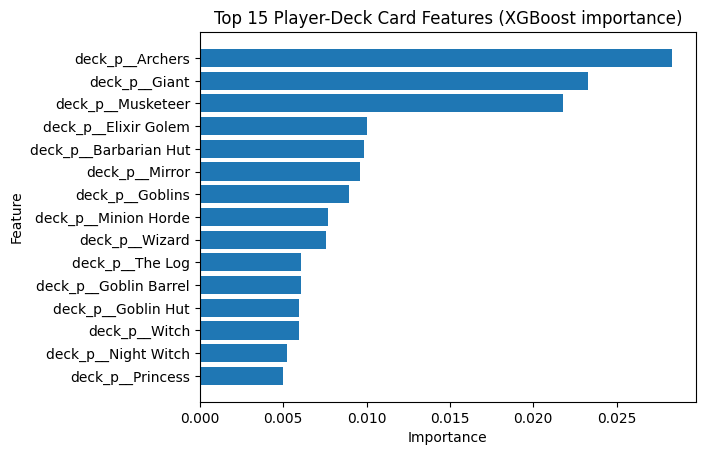

In [24]:
import matplotlib.pyplot as plt

topN = 15
top_plot = player_cards.head(topN).iloc[::-1]  # reverse for nice barh

plt.figure()
plt.barh(top_plot["feature"].astype(str), top_plot["importance"])
plt.title(f"Top {topN} Player-Deck Card Features (XGBoost importance)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

It's important to note that feature importance does not indicate a positive effect.


Top 25 high-lift pairs (min_count=2000) in PLAYER decks:


,cardA,cardB,count,win_rate,lift
0,Goblins,Lightning,3519,0.545325,1.090651
1,Royal Ghost,Elixir Collector,2454,0.543195,1.086390
2,Witch,Wall Breakers,10419,0.540551,1.081102
3,Witch,Hunter,27710,0.540058,1.080115
4,Hunter,Elixir Collector,3702,0.538088,1.076175
5,Elixir Collector,Barbarian Barrel,5600,0.537143,1.074286
6,Dark Prince,Battle Ram,31584,0.535018,1.070035
7,Hunter,Goblin Barrel,34638,0.534096,1.068191
8,Minions,Battle Ram,25848,0.533387,1.066775
9,Three Musketeers,Royal Ghost,4546,0.532556,1.065112



Top 25 by unconventional_score (rare + strong), with safety filter already applied:


,cardA,cardB,count,support,win_rate,lift,unconventional_score
0,Goblins,Lightning,3519,0.000779,0.545325,1.090651,1400.160081
1,Royal Ghost,Elixir Collector,2454,0.000543,0.543195,1.086390,1999.963368
2,Witch,Wall Breakers,10419,0.002306,0.540551,1.081102,468.761775
3,Witch,Hunter,27710,0.006134,0.540058,1.080115,176.094344
4,Hunter,Elixir Collector,3702,0.000819,0.538088,1.076175,1313.281369
5,Elixir Collector,Barbarian Barrel,5600,0.001240,0.537143,1.074286,866.648991
6,Dark Prince,Battle Ram,31584,0.006991,0.535018,1.070035,153.053332
7,Hunter,Goblin Barrel,34638,0.007667,0.534096,1.068191,139.318203
8,Minions,Battle Ram,25848,0.005722,0.533387,1.066775,186.447952
9,Three Musketeers,Royal Ghost,4546,0.001006,0.532556,1.065112,1058.466953


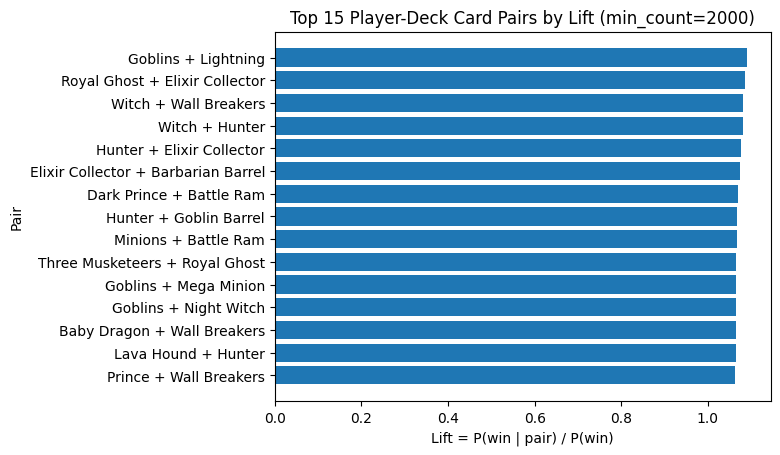

In [29]:
import itertools
from collections import Counter

min_count = 2000 # tune-able threshold to filter out very rare pairs with high variance
pair_total = Counter()
pair_wins = Counter()

# iterate over training set only to avoid data leakage
for cards, y in zip(train_df["cards.p"], train_df["y"]):
    if not isinstance(cards, (list, tuple)) or len(cards) < 2:
        continue
    # sort to keep pairs consistent
    for a, b in itertools.combinations(sorted(cards), 2):
        pair_total[(a, b)] += 1
        pair_wins[(a, b)] += int(y)

baseline = float(train_df["y"].mean())

#Calculate lift (model effectiveness of pairs vs baseline win rate)
rows = []
for (a, b), cnt in pair_total.items():
    if cnt < min_count:
        continue
    wr = pair_wins[(a, b)] / cnt
    lift = wr / baseline if baseline > 0 else np.nan
    rows.append((a, b, cnt, wr, lift))

pair_df = (pd.DataFrame(rows, columns=["cardA_id", "cardB_id", "count", "win_rate", "lift"])
             .sort_values(["lift", "count"], ascending=[False, False])
             .reset_index(drop=True))

pair_df["cardA"] = pair_df["cardA_id"].map(id_to_name)
pair_df["cardB"] = pair_df["cardB_id"].map(id_to_name)

print(f"\nTop 25 high-lift pairs (min_count={min_count}) in PLAYER decks:")
display(pair_df[["cardA", "cardB", "count", "win_rate", "lift"]].head(25))

#Rarity + strength score: lift / support, where lift = P(win | pair) / P(win) 
#and support = count / # of training rows
n_rows = len(train_df)
pair_df["support"] = pair_df["count"] / n_rows
eps = 1e-9
pair_df["unconventional_score"] = pair_df["lift"] / (pair_df["support"] + eps)

print("\nTop 25 by unconventional_score (rare + strong), with safety filter already applied:")
display(pair_df[["cardA", "cardB", "count", "support", "win_rate", "lift", "unconventional_score"]].head(25))

#Visualize top-lift pairs 
top_pairs_plot = pair_df.head(15).iloc[::-1]
labels = (top_pairs_plot["cardA"].astype(str) + " + " + top_pairs_plot["cardB"].astype(str))

plt.figure()
plt.barh(labels, top_pairs_plot["lift"])
plt.title(f"Top 15 Player-Deck Card Pairs by Lift (min_count={min_count})")
plt.xlabel("Lift = P(win | pair) / P(win)")
plt.ylabel("Pair")
plt.show()

In [ ]:
# Map IDs to names
if "id_to_name" in globals() and isinstance(id_to_name, dict):
    pair_df["cardA"] = pair_df["cardA_id"].map(id_to_name).fillna(pair_df["cardA_id"].astype(str))
    pair_df["cardB"] = pair_df["cardB_id"].map(id_to_name).fillna(pair_df["cardB_id"].astype(str))
else:
    pair_df["cardA"] = pair_df["cardA_id"].astype(str)
    pair_df["cardB"] = pair_df["cardB_id"].astype(str)

**Note for Julia:**

I think next steps are just to make visualizations that show that we did something better than random guessing and pull insights wherever is possible. I am looking at the presentation rubric steps 6-8 for this. Also future work is good to look at (I'm thinking just mention that the meta changes and heroes and evos and whatever). Not all of those conclusions need to be in this notebook, because I'm pretty sure we just need to do a presentation, not a write-up but the instructions are hard to follow.